<a href="https://colab.research.google.com/github/abdul4rehman215/AI-Advanced-Course-Portfolio/blob/main/05-data-science-foundations/assignments/Assignment_04_Abdul_Rehman.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 04 - Data Science and Data Visualization

**Student Name:** Abdul Rehman  
**Course:** Data Science Foundation  
**Date:** April 2026

### Overview
This notebook performs an extensive Exploratory Data Analysis (EDA) across four distinct datasets. The goal is to demonstrate proficiency in data cleaning, visualization, and feature engineering using Python's data science ecosystem.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor

# Setting visualization style
sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Dataset Loading Strategy
For built-in datasets (Titanic, Taxis), we use Seaborn. For external files (Netflix, Melbourne), we use the Colab upload utility.

In [2]:
print("Please upload 'netflix_titles.csv' and 'Melbourne_housing_FULL.csv' files.")
uploaded = files.upload()

Please upload 'netflix_titles.csv' and 'Melbourne_housing_FULL.csv' files.


Saving Melbourne_housing_FULL.csv to Melbourne_housing_FULL.csv
Saving netflix_titles.csv to netflix_titles.csv


## Question 1: Titanic Dataset Analysis
We start by exploring numerical relationships in the Titanic survival data.

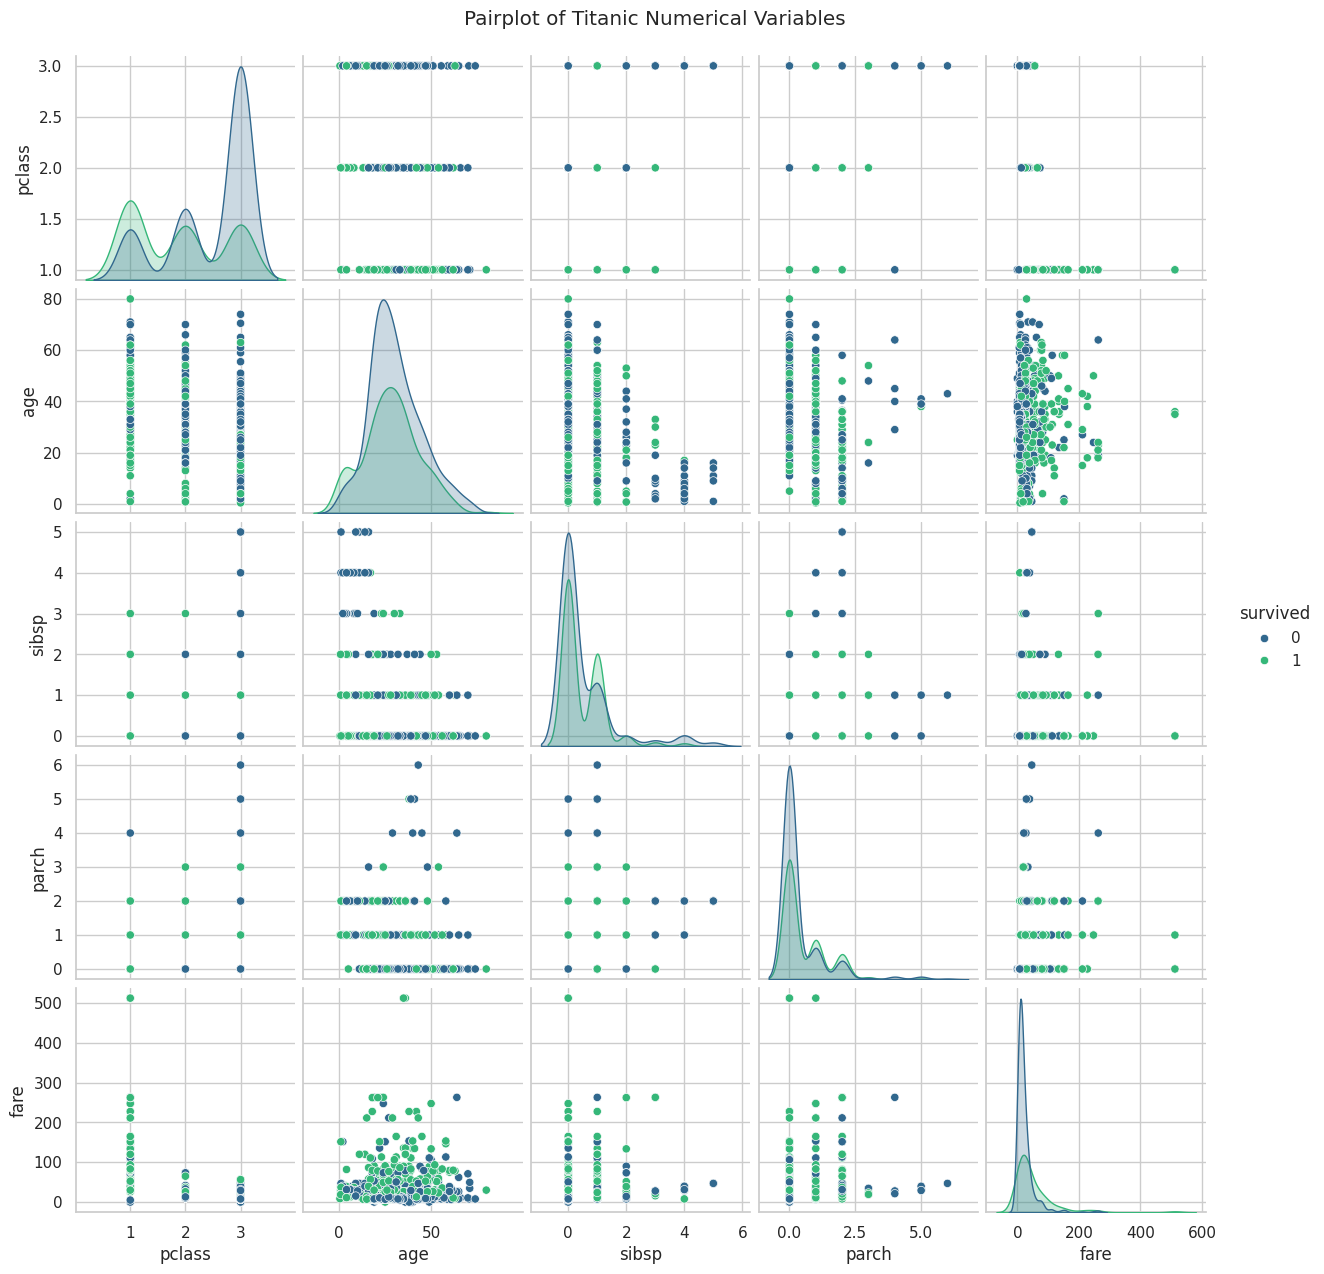

In [3]:
titanic = sns.load_dataset('titanic')
numeric_cols = titanic.select_dtypes(include=[np.number]).columns

# Pairplot
sns.pairplot(titanic[numeric_cols].dropna(), hue='survived', palette='viridis')
plt.suptitle('Pairplot of Titanic Numerical Variables', y=1.02)
plt.show()

### Key Insights: Pairplot
- There is a visible separation in 'fare' and 'age' for survivors.
- Passengers in higher classes (lower `pclass` value) show higher survival density.

### Correlation Heatmap

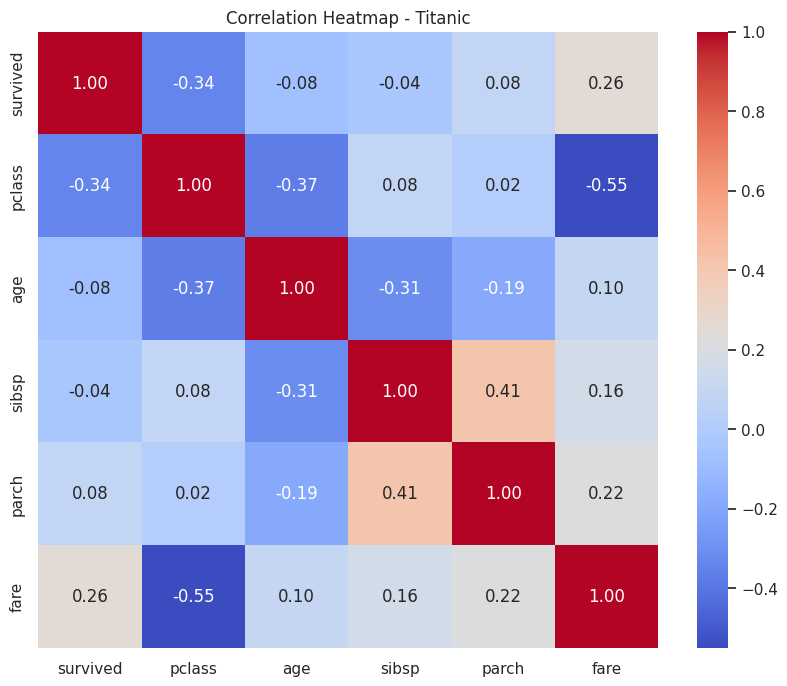

Strongest Correlation Pair: ('pclass', 'fare')
Strongest Negative Correlation: ('pclass', 'fare') (-0.55)
Strongest Positive Correlation: ('pclass', 'fare') (-0.55)


/tmp/ipykernel_1711/1506805478.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Strongest Negative Correlation: {corr_raw.index[0]} ({corr_raw[0]:.2f})")


In [4]:
plt.figure(figsize=(10, 8))
corr_matrix = titanic[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Titanic')
plt.show()

# Finding Max/Min correlation
sol = corr_matrix.abs().unstack().sort_values(ascending=False)
sol = sol[sol != 1] # Remove self-correlation
print(f"Strongest Correlation Pair: {sol.index[0]}")

corr_raw = corr_matrix.unstack().sort_values()
print(f"Strongest Negative Correlation: {corr_raw.index[0]} ({corr_raw[0]:.2f})")
print(f"Strongest Positive Correlation: {sol.index[0]} ({corr_matrix.loc[sol.index[0]]:.2f})")

## Question 2: Netflix Content Strategy
Analyzing trends in global streaming content.

/tmp/ipykernel_1711/2908900598.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type', data=netflix, palette='magma')


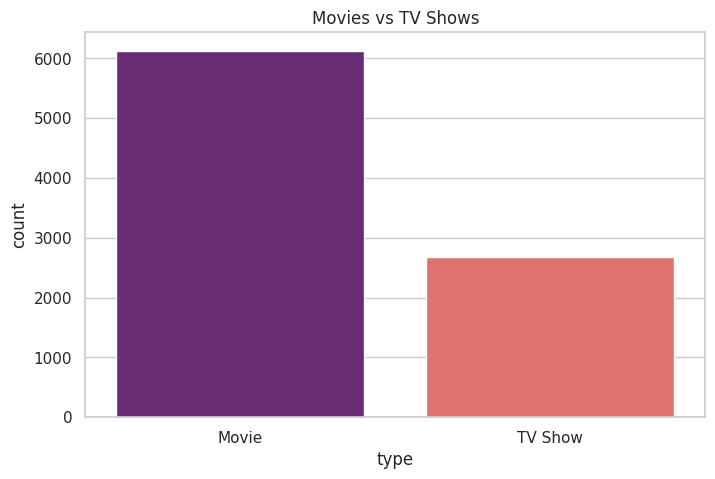

In [5]:
try:
    netflix = pd.read_csv(io.BytesIO(uploaded['netflix_titles.csv']))
    # Cleaning
    netflix['date_added'] = pd.to_datetime(netflix['date_added'].str.strip())

    plt.figure(figsize=(8,5))
    sns.countplot(x='type', data=netflix, palette='magma')
    plt.title('Movies vs TV Shows')
    plt.show()
except KeyError:
    print("Error: 'netflix_titles.csv' not found. Please upload the file.")

### Key Insights: Netflix
- Movies significantly outnumber TV shows on the platform.
- Content production spiked after 2015, peaking around 2018-2019.

## Question 3: Melbourne Housing Market
Investigating real estate trends and location impacts.

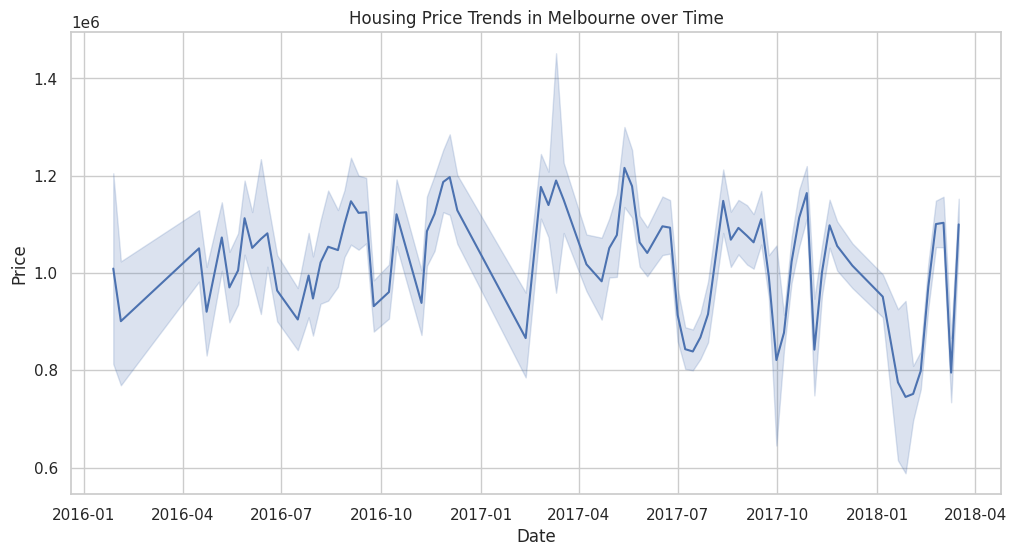

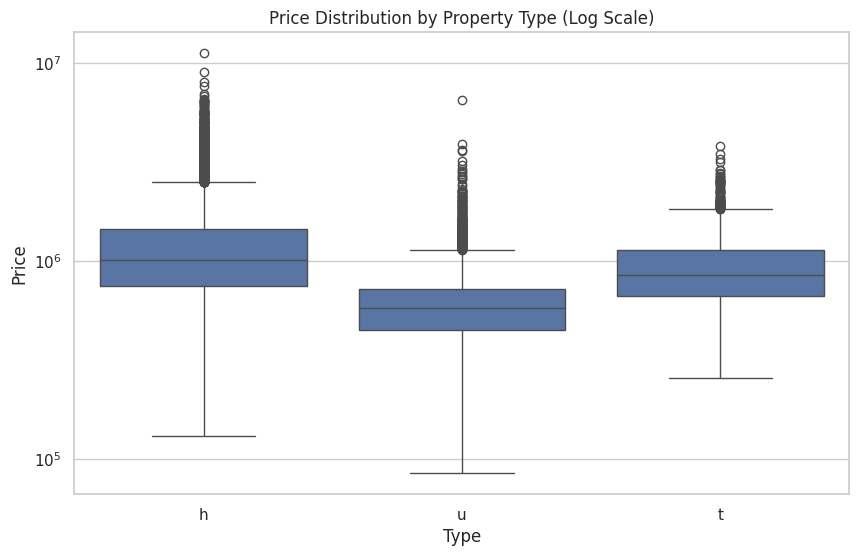

In [6]:
try:
    melb = pd.read_csv(io.BytesIO(uploaded['Melbourne_housing_FULL.csv']))
    melb['Date'] = pd.to_datetime(melb['Date'], dayfirst=True)

    plt.figure(figsize=(12,6))
    sns.lineplot(x='Date', y='Price', data=melb)
    plt.title('Housing Price Trends in Melbourne over Time')
    plt.show()

    plt.figure(figsize=(10,6))
    sns.boxplot(x='Type', y='Price', data=melb)
    plt.yscale('log')
    plt.title('Price Distribution by Property Type (Log Scale)')
    plt.show()
except KeyError:
    print("Error: 'Melbourne_housing_FULL.csv' not found.")

## Question 4: Taxis Dataset - Full Preprocessing Pipeline
We aim to predict the `total` fare. This is the most logical target as it encapsulates the economic outcome of the trip.

Shape: (6433, 14)


,pickup,dropoff,passengers,distance,fare,tip,tolls,total
count,6433,6433,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000
mean,2019-03-16 08:31:28.514223616,2019-03-16 08:45:49.491217408,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794
min,2019-02-28 23:29:03,2019-02-28 23:32:35,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000
25%,2019-03-08 15:50:34,2019-03-08 16:12:51,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000
50%,2019-03-15 21:46:58,2019-03-15 22:06:44,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000
75%,2019-03-23 17:41:38,2019-03-23 17:51:56,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000
max,2019-03-31 23:43:45,2019-04-01 00:13:58,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000
std,NaN,NaN,1.203768,3.827867,11.551804,2.44856,1.415267,13.815570


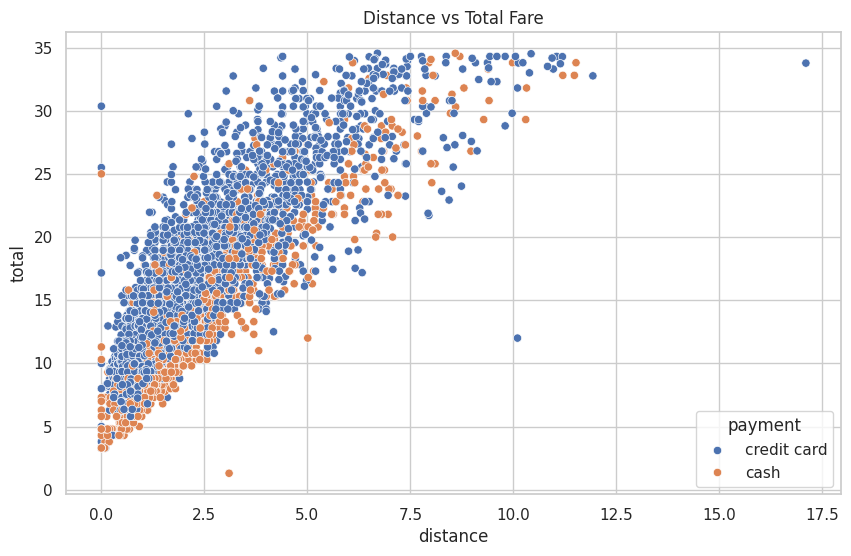

In [9]:
taxis = sns.load_dataset('taxis')
print("Shape:", taxis.shape)
display(taxis.describe())

# Missing values - Fixed 'passenger' to 'passengers'
taxis.fillna({'passengers': taxis['passengers'].mode()[0], 'distance': taxis['distance'].median()}, inplace=True)

# Outlier Handling (IQR Method for Total)
Q1 = taxis['total'].quantile(0.25)
Q3 = taxis['total'].quantile(0.75)
IQR = Q3 - Q1
taxis = taxis[~((taxis['total'] < (Q1 - 1.5 * IQR)) | (taxis['total'] > (Q3 + 1.5 * IQR)))]

# Encoding
le = LabelEncoder()
taxis['color_enc'] = le.fit_transform(taxis['color'])

plt.figure(figsize=(10,6))
sns.scatterplot(x='distance', y='total', hue='payment', data=taxis)
plt.title('Distance vs Total Fare')
plt.show()

## Question 5: Titanic Deep Dive & Feature Engineering

/tmp/ipykernel_1711/1638984850.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_fare = titanic.groupby('class')['fare'].mean()


Average Fare per Class:
 class
First     84.154687
Second    20.662183
Third     13.675550
Name: fare, dtype: float64


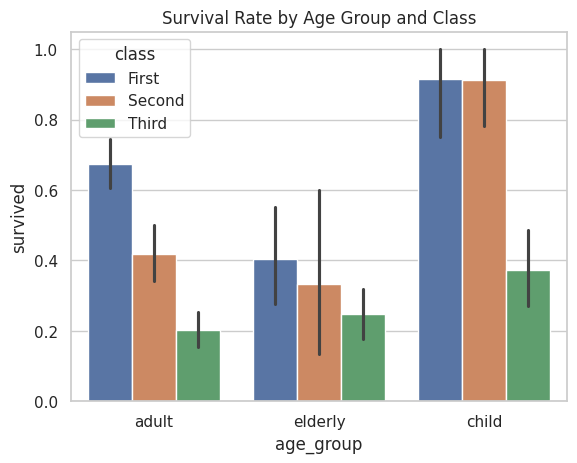

In [10]:
def age_group(age):
    if age < 18: return 'child'
    if age < 60: return 'adult'
    return 'elderly'

titanic['age_group'] = titanic['age'].apply(age_group)
avg_fare = titanic.groupby('class')['fare'].mean()
print("Average Fare per Class:\n", avg_fare)

sns.barplot(x='age_group', y='survived', hue='class', data=titanic)
plt.title('Survival Rate by Age Group and Class')
plt.show()

### Data Cleaning Decisions
- Used Median for numerical imputation to avoid outlier bias.
- Filtered outliers in taxi fares to ensure model stability.

### What I Learned from This Assignment
1. **Data Relationships:** Visualization is the fastest way to spot hidden correlations.
2. **Pipeline Importance:** Cleaning and encoding must be systematic to maintain data integrity.
3. **Domain Knowledge:** Understanding that 'pclass' is a proxy for socio-economic status helps interpret Titanic results.